<a href="https://colab.research.google.com/github/Adityabehl/ML_Learning/blob/main/Multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)

Saving Dataset_2_fertilizer.csv to Dataset_2_fertilizer.csv
Saving Dataset_1_watermelon.csv to Dataset_1_watermelon.csv
Uploaded file: Dataset_2_fertilizer.csv
Uploaded file: Dataset_1_watermelon.csv


Merged Dataset:


,Year,Yield,Fertilizer_Use
0,2000,45000.00,94.00
27,2000,14500.00,94.00
28,2001,15755.62,96.71
1,2001,46425.31,96.71
2,2002,47709.77,98.56



--- Model Coefficients ---
Intercept: -1233317.0807887781
Year Coefficient: 630.5094672962889
Fertilizer Coefficient: 25.67024415461958

--- Multivariate Linear Regression Metrics ---
MSE         : 282866083.7007
RMSE        : 16818.6231
MAE         : 16783.9407
R2          : 0.0984
Adjusted R2 : 0.0630

--- Actual vs Predicted Yield ---
 Year    Yield  Predicted_Yield  Difference (Error)
 2022 62500.01     45691.082652        16808.927348
 2022 27066.04     45691.082652       -18625.042652
 2023 28138.89     46452.767067       -18313.877067
 2023 63499.46     46452.767067        17046.692933
 2024 64756.11     47202.643169        17553.466831
 2024 29448.98     47202.643169       -17753.663169
 2025 30571.65     47930.956267       -17359.306267
 2025 66170.41     47930.956267        18239.453733
 2026 67604.20     48634.369227        18969.830773
 2026 31195.92     48634.369227       -17438.449227


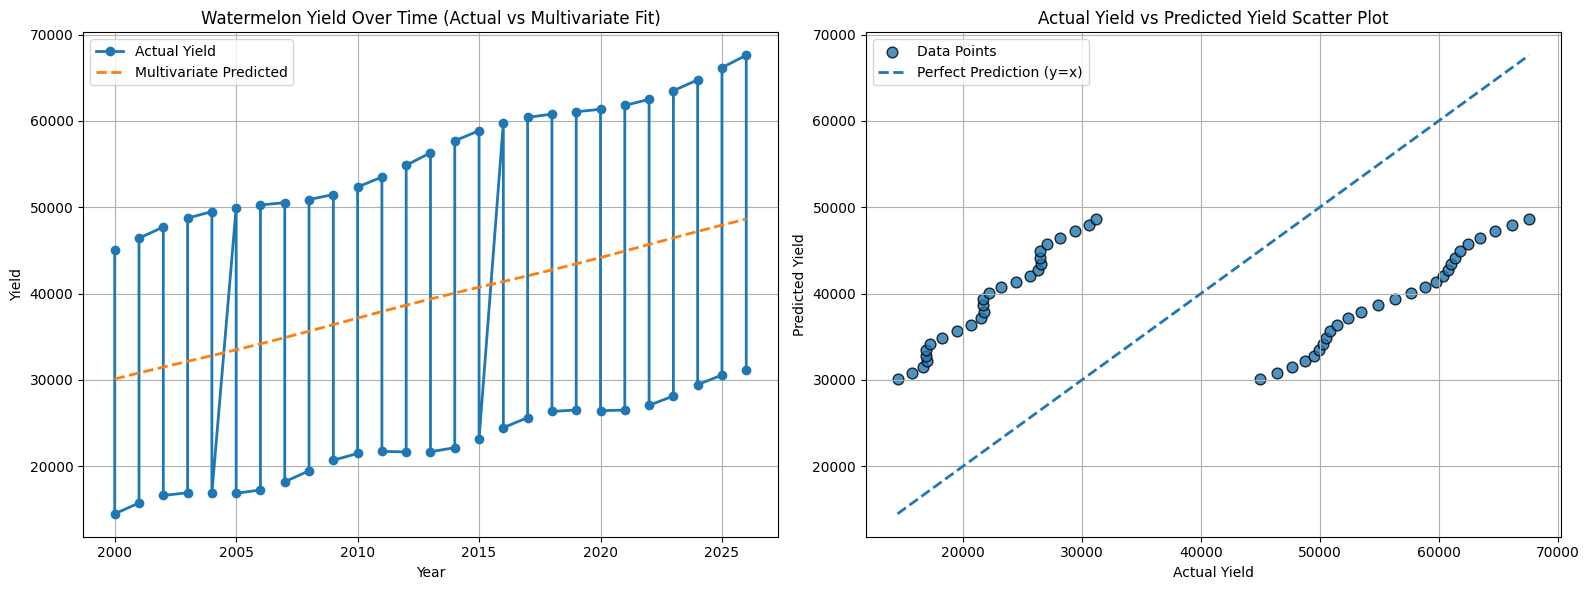

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATASETS
# ==========================================

df_watermelon = pd.read_csv('Dataset_1_watermelon.csv')
df_fert = pd.read_csv('Dataset_2_fertilizer.csv')


# ==========================================
# 2. EXTRACT REQUIRED COLUMNS
# ==========================================

df_yield = df_watermelon[
    ['Year', 'Value']
].rename(
    columns={'Value': 'Yield'}
)

df_fertilizer = df_fert[
    ['Year', 'Value']
].rename(
    columns={'Value': 'Fertilizer_Use'}
)


# ==========================================
# 3. MERGE DATASETS
# ==========================================

df_merged = pd.merge(
    df_yield,
    df_fertilizer,
    on='Year',
    how='inner'
).sort_values('Year')

print("Merged Dataset:")
display(df_merged.head())


# ==========================================
# 4. FEATURES AND TARGET
# ==========================================

# Input variables
X = df_merged[
    ['Year', 'Fertilizer_Use']
].values

# Target variable
Y = df_merged[
    'Yield'
].values


# ==========================================
# 5. ADD INTERCEPT COLUMN
# ==========================================

X_design = np.hstack([
    np.ones((len(X), 1)),
    X
])


# ==========================================
# 6. MULTIVARIATE LINEAR REGRESSION
# Normal Equation
# ==========================================

beta_multi = (
    np.linalg.inv(
        X_design.T @ X_design
    )
    @ X_design.T
    @ Y
)

# Make predictions
Y_pred = X_design @ beta_multi


# ==========================================
# 7. SHOW MODEL COEFFICIENTS
# ==========================================

print("\n--- Model Coefficients ---")

print(
    "Intercept:",
    beta_multi[0]
)

print(
    "Year Coefficient:",
    beta_multi[1]
)

print(
    "Fertilizer Coefficient:",
    beta_multi[2]
)


# ==========================================
# 8. CALCULATE ALL METRICS
# ==========================================

def calculate_all_metrics(
    y_true,
    y_pred,
    k_features
):

    n = len(y_true)

    mse = np.mean(
        (y_true - y_pred) ** 2
    )

    rmse = np.sqrt(mse)

    mae = np.mean(
        np.abs(y_true - y_pred)
    )

    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    r2 = 1 - (
        ss_res / ss_tot
    )

    adj_r2 = 1 - (
        (1 - r2) *
        (n - 1) /
        (n - k_features - 1)
    )

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Adjusted R2": adj_r2
    }


# Calculate metrics

metrics = calculate_all_metrics(
    Y,
    Y_pred,
    k_features=2
)


# ==========================================
# 9. PRINT METRICS
# ==========================================

print(
    "\n--- Multivariate Linear Regression Metrics ---"
)

for metric_name, value in metrics.items():

    print(
        f"{metric_name:<12}: {value:.4f}"
    )


# ==========================================
# 10. ACTUAL VS PREDICTED TABLE
# ==========================================

df_merged[
    'Predicted_Yield'
] = Y_pred

df_merged[
    'Difference (Error)'
] = Y - Y_pred


print(
    "\n--- Actual vs Predicted Yield ---"
)

print(
    df_merged[
        [
            'Year',
            'Yield',
            'Predicted_Yield',
            'Difference (Error)'
        ]
    ].tail(10).to_string(
        index=False
    )
)


# ==========================================
# 11. VISUALIZATION
# ==========================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)


# Graph 1: Actual vs Predicted

ax1.plot(
    df_merged['Year'],
    df_merged['Yield'],
    marker='o',
    linewidth=2,
    label='Actual Yield'
)

ax1.plot(
    df_merged['Year'],
    df_merged['Predicted_Yield'],
    linestyle='--',
    linewidth=2,
    label='Multivariate Predicted'
)

ax1.set_title(
    'Watermelon Yield Over Time (Actual vs Multivariate Fit)'
)

ax1.set_xlabel('Year')

ax1.set_ylabel('Yield')

ax1.grid(True)

ax1.legend()


# Graph 2: Actual vs Predicted Scatter Plot

ax2.scatter(
    Y,
    Y_pred,
    alpha=0.8,
    edgecolors='black',
    s=60,
    label='Data Points'
)

min_val = min(
    Y.min(),
    Y_pred.min()
)

max_val = max(
    Y.max(),
    Y_pred.max()
)


# Perfect prediction line

ax2.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction (y=x)'
)

ax2.set_title(
    'Actual Yield vs Predicted Yield Scatter Plot'
)

ax2.set_xlabel(
    'Actual Yield'
)

ax2.set_ylabel(
    'Predicted Yield'
)

ax2.grid(True)

ax2.legend()


plt.tight_layout()

plt.show()